In [1]:
from orca_models import H1esc_1M
import torch
import numpy as np
import pandas as pd

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Instantiate the model
model = H1esc_1M()
model.to(device)

H1esc_1M(
  (net): DataParallel(
    (module): Net(
      (lconv1): Sequential(
        (0): Conv1d(4, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Conv1d(64, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv1): Sequential(
        (0): Conv1d(64, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(64, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (lconv2): Sequential(
        (0): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
        (1): Conv1d(64, 96, kernel

In [4]:
import random
from pyfaidx import Fasta

In [5]:
model.eval()

H1esc_1M(
  (net): DataParallel(
    (module): Net(
      (lconv1): Sequential(
        (0): Conv1d(4, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Conv1d(64, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv1): Sequential(
        (0): Conv1d(64, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(64, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (lconv2): Sequential(
        (0): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
        (1): Conv1d(64, 96, kernel

In [6]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence

In [7]:
BED_FILE = "/project/fudenber_735/tensorflow_models/akita/v2/data/mm10/sequences.bed"

In [8]:
df = pd.read_csv(BED_FILE, sep="\t", header=None, names=["chrom", "start", "end", "fold"])

In [9]:
FOLD = 0

In [10]:
df = df[df["fold"] == f"fold{FOLD}"].reset_index(drop=True)

In [11]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [12]:
akita_length = 1310720
orca_length = 2000000

In [13]:
difference = (orca_length - (akita_length)) // 2

In [14]:
df["orca_start"] = df["start"] - difference
df["orca_end"] = df["end"] + difference

In [15]:
mm10_chrom_sizes = {
    'chr1': 195471971,
    'chr2': 182113224,
    'chr3': 160039680,
    'chr4': 156508116,
    'chr5': 151834684,
    'chr6': 149736546,
    'chr7': 145441459,
    'chr8': 129401213,
    'chr9': 124595110,
    'chr10': 130694993,
    'chr11': 122082543,
    'chr12': 120129022,
    'chr13': 120421639,
    'chr14': 124902244,
    'chr15': 104043685,
    'chr16': 98207768,
    'chr17': 94987271,
    'chr18': 90702639,
    'chr19': 61431566,
    'chrX': 171031299,
    'chrY': 91744698
}


In [16]:
# Make sure chrom names are strings
df['chrom'] = df['chrom'].astype(str)

# Check for orca_start < 0
negative_start = df[df['orca_start'] < 0]

# Check for orca_end > chromosome length
out_of_bounds_end = df[df.apply(lambda row: row['orca_end'] > mm10_chrom_sizes.get(row['chrom'], float('inf')), axis=1)]

print(f"Regions with negative start:\n{negative_start}")
print(f"\nRegions with orca_end > chromosome size:\n{out_of_bounds_end}")

Regions with negative start:
Empty DataFrame
Columns: [chrom, start, end, fold, orca_start, orca_end]
Index: []

Regions with orca_end > chromosome size:
Empty DataFrame
Columns: [chrom, start, end, fold, orca_start, orca_end]
Index: []


In [ ]:
# df.to_csv("/scratch1/smaruj/orca_validation/orca_validation_fold0.tsv", sep='\t', index=False)

In [17]:
from torch.utils.data import Dataset, DataLoader

In [18]:
class GenomicSequenceDataset(Dataset):
    def __init__(self, coord_df, genome_fasta, transform_fn=None):
        self.coords = coord_df  # DataFrame with chrom, start, end
        self.genome = genome_fasta
        self.transform_fn = transform_fn  # Optional function to modify sequence

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        TARGET_LEN = 2000000
        
        row = self.coords.iloc[idx]
        chrom, start, end = row["chrom"], row["orca_start"], row["orca_end"]
        seq = self.genome[chrom][start:end].seq.upper()
        
        # Fix sequence length if needed
        if len(seq) != TARGET_LEN:
            seq = seq[:TARGET_LEN].ljust(TARGET_LEN, 'N')  # pad with Ns if needed
        
        # Apply transformation, e.g. permute a window
        if self.transform_fn is not None:
            seq = self.transform_fn(seq, row)  # Pass row in case you want loc info
        
        one_hot = one_hot_encode_sequence(seq)  # shape: (4, L)
        return torch.from_numpy(one_hot.copy())

In [19]:
orig_dataset = GenomicSequenceDataset(df, genome)

In [20]:
orig_loader = DataLoader(orig_dataset, batch_size=16, shuffle=False, drop_last=False)

In [21]:
output_dir = "/scratch1/smaruj/orca_validation/fold0_orca_preds"

In [22]:
center = 250  # center of the 500x500 map
half = 128    # half of the 256-bin window
global_row_idx = 0  # tracks correct row in df

with torch.no_grad():
    for batch_idx, orig_batch in enumerate(orig_loader):
        orig_batch = orig_batch.squeeze(1)
        orig_preds = model(orig_batch.to(device)).cpu()
        
        # Remove the channel dimension → shape [B, 500, 500]
        pred_maps = orig_preds.squeeze(1)
        
        # Crop center 256×256 window
        cropped_maps = pred_maps[
            :, 
            center - half : center + half,
            center - half : center + half
        ]  # shape: [B, 256, 256]
        
        # Vectorize upper triangle (including diagonal)
        triu_indices = torch.triu_indices(256, 256)
        vecs = cropped_maps[:, triu_indices[0], triu_indices[1]]  # shape: [B, N]
        
        current_batch_size = vecs.shape[0]
        
        # Save each prediction separately
        for i in range(current_batch_size):
            row = df.iloc[global_row_idx]
            chrom = row["chrom"]
            start = int(row["start"])
            end = int(row["end"])

            filename = f"{chrom}_{start}_{end}_orca_pred.pt"
            torch.save(vecs[i], f"{output_dir}/{filename}")
            print("Saving index: ", global_row_idx)

            global_row_idx += 1

/home1/smaruj/miniconda3/envs/orca_env/lib/python3.9/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home1/smaruj/miniconda3/envs/orca_env/lib/python3.9/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Saving index:  0
Saving index:  1
Saving index:  2
Saving index:  3
Saving index:  4
Saving index:  5
Saving index:  6
Saving index:  7
Saving index:  8
Saving index:  9
Saving index:  10
Saving index:  11
Saving index:  12
Saving index:  13
Saving index:  14
Saving index:  15
Saving index:  16
Saving index:  17
Saving index:  18
Saving index:  19
Saving index:  20
Saving index:  21
Saving index:  22
Saving index:  23
Saving index:  24
Saving index:  25
Saving index:  26
Saving index:  27
Saving index:  28
Saving index:  29
Saving index:  30
Saving index:  31
Saving index:  32
Saving index:  33
Saving index:  34
Saving index:  35
Saving index:  36
Saving index:  37
Saving index:  38
Saving index:  39
Saving index:  40
Saving index:  41
Saving index:  42
Saving index:  43
Saving index:  44
Saving index:  45
Saving index:  46
Saving index:  47
Saving index:  48
Saving index:  49
Saving index:  50
Saving index:  51
Saving index:  52
Saving index:  53
Saving index:  54
Saving index:  55
Sa

## Example map

In [27]:
# df

In [28]:
chrom = "chr5"
start = 62858688
end = 64858688

In [29]:
sequence = genome[chrom][start:end]
X = one_hot_encode_sequence(sequence)
X_tensor = torch.tensor(X).to(device)

In [30]:
# --- Run prediction ---
with torch.no_grad():
    output = model(X_tensor)

/home1/smaruj/miniconda3/envs/orca_env/lib/python3.9/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home1/smaruj/miniconda3/envs/orca_env/lib/python3.9/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [32]:
center = 250
half = 128

In [43]:
cropped_map = output[0, 0, center - half : center + half,
                            center - half : center + half]

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# let's assume that 2048bp (1 Akita bin) is ~2kb
# then, we need central 256 bins from the ORCA prediction

In [45]:
if isinstance(cropped_map, torch.Tensor):
    cropped_map = cropped_map.cpu().numpy()

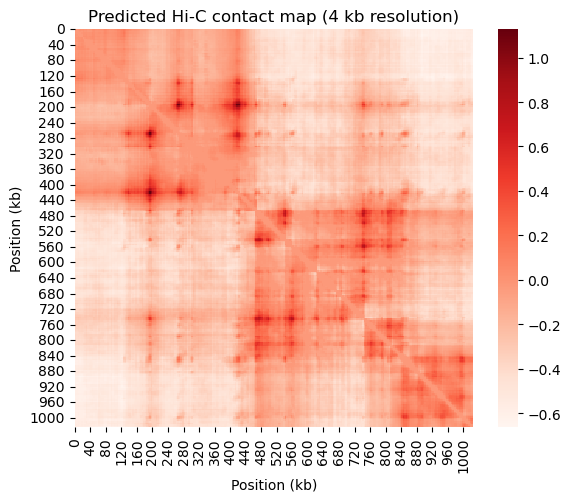

In [47]:
bin_size_kb = 4

# Tick positions and labels (every 10 bins)
tick_pos = np.arange(0, 256, 10)
tick_labels = [str(t * bin_size_kb) for t in tick_pos]

plt.figure(figsize=(6, 5))
ax = sns.heatmap(cropped_map, cmap="Reds", square=True, cbar=True)

# Set ticks explicitly
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos)
ax.set_yticklabels(tick_labels)

plt.title("Predicted Hi-C contact map (4 kb resolution)")
plt.xlabel("Position (kb)")
plt.ylabel("Position (kb)")
plt.tight_layout()
plt.show()